# Indian Stock Portfolio Analysis

In [1]:
# Importing Libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Stocks data
stocks = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS"
]

stocks

['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'ICICIBANK.NS']

In [8]:
# Downloading stock data
data = yf.download(
    stocks,
    start='2020-01-01',
    auto_adjust=True,
    progress=False
)

In [9]:
data.head()

Price            Close                                                    \
Ticker     HDFCBANK.NS ICICIBANK.NS     INFY.NS RELIANCE.NS       TCS.NS   
Date                                                                       
2020-01-01  605.529358   519.137939  633.151184  675.324158  1866.114014   
2020-01-02  609.389160   522.861572  631.303650  686.821228  1857.547974   
2020-01-03  600.698792   521.169006  641.013367  687.648743  1894.567139   
2020-01-06  587.698792   508.450470  634.869690  671.700684  1894.394775   
2020-01-07  597.004822   505.742401  625.460632  682.034546  1899.043945   

Price             High                                                    ...  \
Ticker     HDFCBANK.NS ICICIBANK.NS     INFY.NS RELIANCE.NS       TCS.NS  ...   
Date                                                                      ...   
2020-01-01  606.192392   524.699268  635.857897  683.152852  1880.146719  ...   
2020-01-02  609.981145   524.118963  636.545159  689.348791  1876.746367  ...   
2020-01-03  608.560338   523.055034  642.731901  689.661834  1913.808618  ...   
2020-01-06  597.573144   519.621474  647.715748  683.510767  1916.348043  ...   
2020-01-07  602.143238   518.025636  638.091819  686.463335  1906.619807  ...   

Price             Open                                                    \
Ticker     HDFCBANK.NS ICICIBANK.NS     INFY.NS RELIANCE.NS       TCS.NS   
Date                                                                       
2020-01-01  604.345388   522.184604  631.561560  679.081936  1866.458295   
2020-01-02  605.718854   518.412533  634.912583  676.397899  1876.746367   
2020-01-03  607.234269   520.346921  630.616254  685.792191  1863.014777   
2020-01-06  596.720663   519.621474  641.099379  679.976719  1898.311969   
2020-01-07  596.199746   513.866741  634.139210  679.529321  1894.437979   

Price           Volume                                             
Ticker     HDFCBANK.NS ICICIBANK.NS  INFY.NS RELIANCE.NS   TCS.NS  
Date                                                               
2020-01-01     3673698      7642793  2112415    14004468  1354908  
2020-01-02     6137166     10264223  5658200    17710316  2380752  
2020-01-03    10855550      9594690  7882938    20984698  4655761  
2020-01-06    10890186     12534334  6519403    24519177  3023209  
2020-01-07    14724494     16101835  7899363    16683622  2429317  

[5 rows x 25 columns]

In [10]:
# Keep only close prices
prices = data["Close"]
prices.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2020-01-01,605.529358,519.137939,633.151184,675.324158,1866.114014
2020-01-02,609.389160,522.861572,631.303650,686.821228,1857.547974
2020-01-03,600.698792,521.169006,641.013367,687.648743,1894.567139
2020-01-06,587.698792,508.450470,634.869690,671.700684,1894.394775
2020-01-07,597.004822,505.742401,625.460632,682.034546,1899.043945


In [11]:
# Daily Returns
returns = prices.pct_change().dropna()
returns.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2020-01-02,0.006374,0.007173,-0.002918,0.017025,-0.004590
2020-01-03,-0.014261,-0.003237,0.015380,0.001205,0.019929
2020-01-06,-0.021641,-0.024404,-0.009584,-0.023192,-0.000091
2020-01-07,0.015835,-0.005326,-0.014820,0.015385,0.002454
2020-01-08,-0.002618,0.005833,-0.013326,-0.007510,0.022395


In [12]:
# Correlation Matrix
corr_matrix = returns.corr()
corr_matrix

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Ticker,,,,,
HDFCBANK.NS,1.000000,0.635800,0.335582,0.437707,0.299917
ICICIBANK.NS,0.635800,1.000000,0.349307,0.416075,0.312039
INFY.NS,0.335582,0.349307,1.000000,0.339079,0.721123
RELIANCE.NS,0.437707,0.416075,0.339079,1.000000,0.367464
TCS.NS,0.299917,0.312039,0.721123,0.367464,1.000000


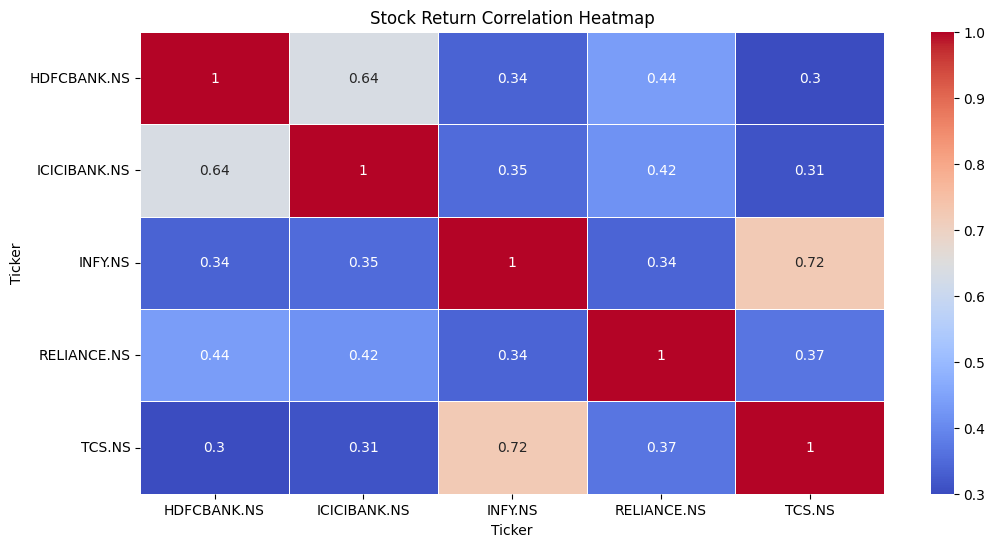

In [13]:
# Correlation HEATMAP
plt.figure(figsize=(12,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Stock Return Correlation Heatmap")

plt.show()

In [14]:
# Annualized Returns
annual_returns = returns.mean() * 252    # 252 trading days
annual_returns

Ticker
HDFCBANK.NS     0.068635
ICICIBANK.NS    0.182969
INFY.NS         0.125891
RELIANCE.NS     0.152261
TCS.NS          0.058067
dtype: float64

In [15]:
# Annualized Volatility
annual_volatility = returns.std() * np.sqrt(252)
annual_volatility

Ticker
HDFCBANK.NS     0.257545
ICICIBANK.NS    0.294295
INFY.NS         0.276519
RELIANCE.NS     0.281224
TCS.NS          0.240844
dtype: float64

In [16]:
# Portfolio weights
num_stocks = len(stocks)

weights = np.array([1/num_stocks]*num_stocks)

weights

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [17]:
# Portfolio Returns
portfolio_returns = np.dot(weights,annual_returns)
portfolio_returns

np.float64(0.11756460292183699)

In [18]:
# Portfolio Volatility
cov_matrix = returns.cov() * 252

portfolio_var = np.dot(
    weights.T,
    np.dot(cov_matrix,weights)
)

portfolio_volatility = np.sqrt(portfolio_var)

portfolio_volatility

np.float64(0.19797007867029542)

In [19]:
# Sharpe Ratio
risk_free_rate = 0.065

sharpe_ratio = (portfolio_returns - risk_free_rate) / portfolio_volatility

sharpe_ratio

np.float64(0.26551791702512506)

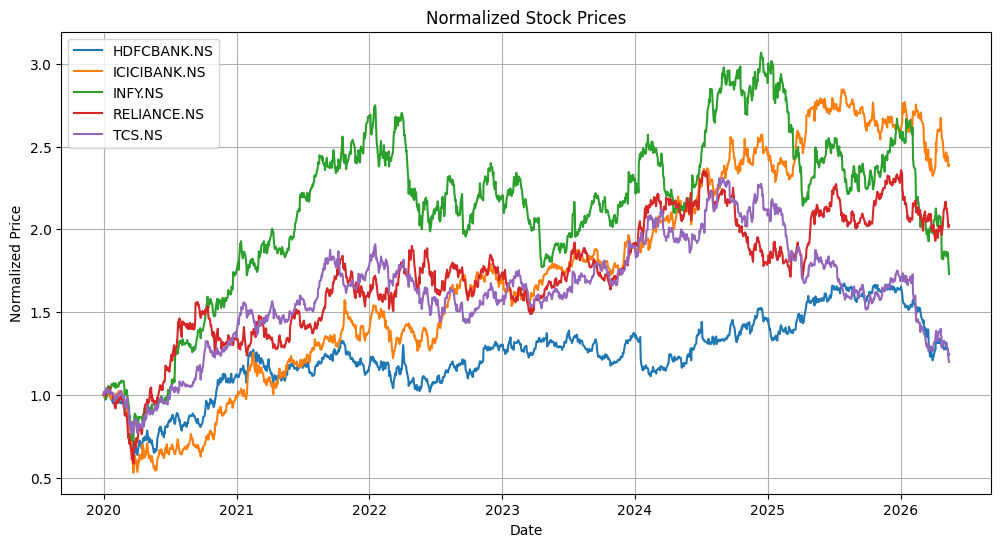

In [20]:
# Normalized Price Plot
normalized_prices = prices / prices.iloc[0]

plt.figure(figsize=(12,6))

for column in normalized_prices.columns:
    plt.plot(normalized_prices.index, normalized_prices[column], label=column)

plt.title("Normalized Stock Prices")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
# Portfolio Summary

summary = pd.DataFrame({
    "Metric": [
        "Expected Annual Return",
        "Annual Volatility",
        "Sharpe Ratio"
    ],
    "Value": [
        portfolio_returns,
        portfolio_volatility,
        sharpe_ratio
    ]
})

summary

,Metric,Value
0,Expected Annual Return,0.117565
1,Annual Volatility,0.197970
2,Sharpe Ratio,0.265518
